In [1]:
!pip install wfdb pandas matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 2.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wfdb
import ast
import os
import urllib.request
import shutil

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [3]:
base_url = "https://physionet.org/files/ptb-xl/1.0.3/"

urllib.request.urlretrieve(
    base_url + "ptbxl_database.csv",
    "ptbxl_database.csv"
)

urllib.request.urlretrieve(
    base_url + "scp_statements.csv",
    "scp_statements.csv"
)

print("Arquivos do PTB-XL baixados com sucesso!")

Arquivos do PTB-XL baixados com sucesso!


In [4]:
# Abrindo os arquivos
df = pd.read_csv("ptbxl_database.csv", index_col="ecg_id")
scp = pd.read_csv("scp_statements.csv", index_col=0)

# Transformando a coluna scp_codes em um formato que o Python consegue interpretar
df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval)

# Pegando apenas classificações diagnósticas
diagnostic_scp = scp[scp["diagnostic"] == 1]

def identificar_superclasses(scp_codes):
    classes = set()

    for codigo in scp_codes.keys():
        if codigo in diagnostic_scp.index:
            classe = diagnostic_scp.loc[codigo, "diagnostic_class"]

            if pd.notna(classe):
                classes.add(classe)

    return list(classes)

df["superclasses"] = df["scp_codes"].apply(identificar_superclasses)

print(df[["age", "sex", "superclasses"]].head())

         age  sex superclasses
ecg_id                        
1       56.0    1       [NORM]
2       19.0    0       [NORM]
3       37.0    1       [NORM]
4       24.0    0       [NORM]
5       19.0    1       [NORM]


In [5]:
categorias = ["NORM", "MI", "STTC", "CD", "HYP"]

selecionados = []

for categoria in categorias:

    dados_categoria = df[
        df["superclasses"].apply(lambda x: categoria in x)
    ].head(20).copy()

    dados_categoria["categoria_escolhida"] = categoria

    selecionados.append(dados_categoria)

amostra = pd.concat(selecionados)

print("Quantidade total selecionada:", len(amostra))

print()
print(amostra["categoria_escolhida"].value_counts())

Quantidade total selecionada: 100

categoria_escolhida
NORM    20
MI      20
STTC    20
CD      20
HYP     20
Name: count, dtype: int64


In [6]:
pasta_principal = "Dados_Visuais_ECG"

os.makedirs(pasta_principal, exist_ok=True)

for categoria in categorias:
    os.makedirs(
        os.path.join(pasta_principal, categoria),
        exist_ok=True
    )

print("Pastas criadas com sucesso!")

Pastas criadas com sucesso!


In [7]:
os.makedirs("ecg_raw", exist_ok=True)

def baixar_ecg(caminho):

    # Exemplo de caminho:
    # records100/00000/00001_lr

    url_base = base_url + caminho

    nome = caminho.split("/")[-1]

    arquivo_hea = os.path.join("ecg_raw", nome + ".hea")
    arquivo_dat = os.path.join("ecg_raw", nome + ".dat")

    if not os.path.exists(arquivo_hea):
        urllib.request.urlretrieve(
            url_base + ".hea",
            arquivo_hea
        )

    if not os.path.exists(arquivo_dat):
        urllib.request.urlretrieve(
            url_base + ".dat",
            arquivo_dat
        )

    return os.path.join("ecg_raw", nome)

In [8]:
primeiro = amostra.iloc[0]

caminho = primeiro["filename_lr"]

print("ECG escolhido:")
print(caminho)

arquivo_local = baixar_ecg(caminho)

sinal, informacoes = wfdb.rdsamp(arquivo_local)

print()
print("ECG carregado com sucesso!")
print("Formato do sinal:", sinal.shape)
print("Derivações:", informacoes["sig_name"])

ECG escolhido:
records100/00000/00001_lr

ECG carregado com sucesso!
Formato do sinal: (1000, 12)
Derivações: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


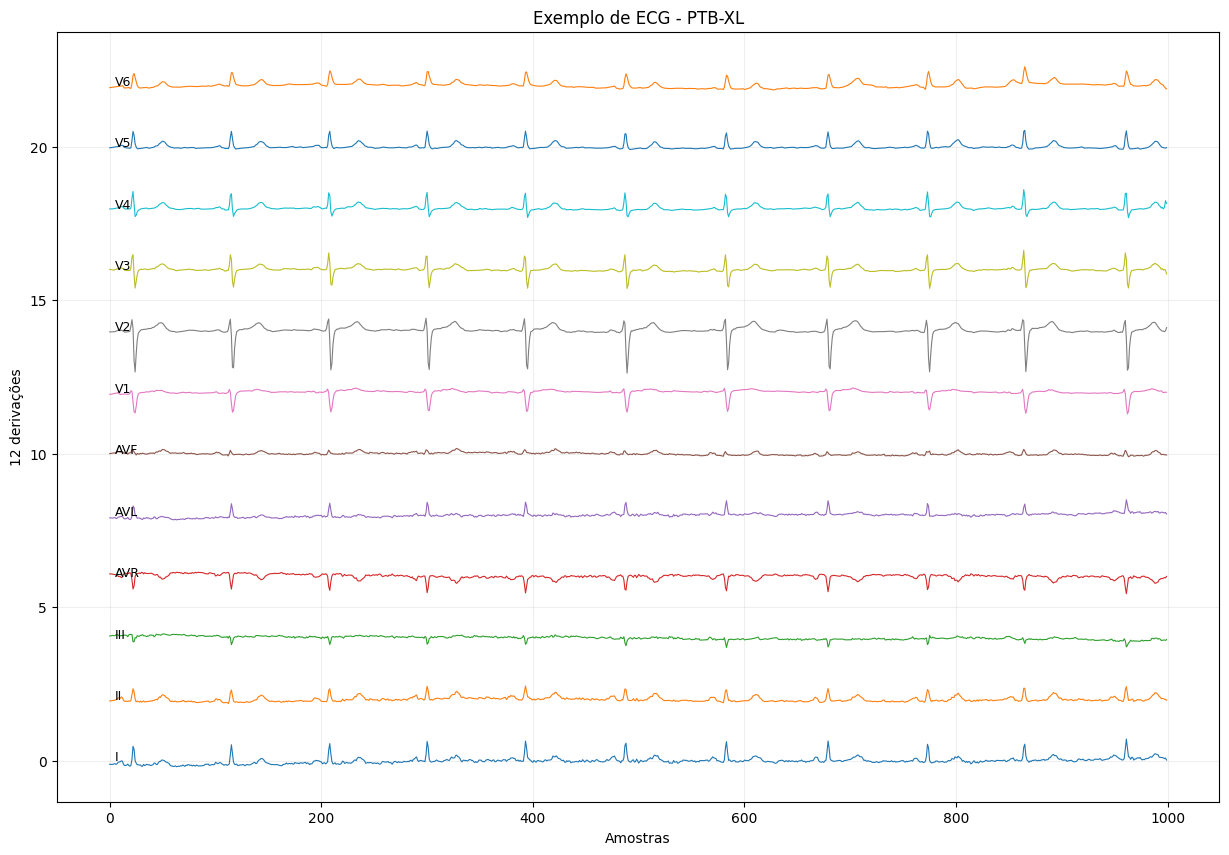

In [9]:
plt.figure(figsize=(15, 10))

nomes = informacoes["sig_name"]

for i in range(12):

    plt.plot(
        sinal[:, i] + i * 2,
        linewidth=0.8
    )

    plt.text(
        5,
        i * 2,
        nomes[i],
        fontsize=9
    )

plt.title("Exemplo de ECG - PTB-XL")
plt.xlabel("Amostras")
plt.ylabel("12 derivações")
plt.grid(True, alpha=0.2)

plt.show()

In [10]:
contador = 1

for ecg_id, registro in amostra.iterrows():

    categoria = registro["categoria_escolhida"]

    try:

        # Baixa o ECG
        caminho_local = baixar_ecg(
            registro["filename_lr"]
        )

        # Abre o ECG
        sinal, info = wfdb.rdsamp(caminho_local)

        nomes_derivacoes = info["sig_name"]

        # Cria a imagem
        plt.figure(figsize=(15, 10))

        for i in range(12):

            plt.plot(
                sinal[:, i] + i * 2,
                linewidth=0.7
            )

            plt.text(
                5,
                i * 2,
                nomes_derivacoes[i],
                fontsize=8
            )

        plt.title(
            f"ECG PTB-XL | ID {ecg_id} | Classe {categoria}"
        )

        plt.xlabel("Amostras")
        plt.ylabel("Derivações")
        plt.grid(True, alpha=0.15)

        nome_arquivo = (
            f"{categoria}_ECG_{contador:03d}_ID_{ecg_id}.png"
        )

        destino = os.path.join(
            pasta_principal,
            categoria,
            nome_arquivo
        )

        plt.savefig(
            destino,
            dpi=150,
            bbox_inches="tight"
        )

        plt.close()

        print(
            f"{contador}/100 - {categoria} - ECG {ecg_id}"
        )

        contador += 1

    except Exception as erro:

        print(
            f"Erro no ECG {ecg_id}: {erro}"
        )

print()
print("PROCESSO FINALIZADO!")

1/100 - NORM - ECG 1
2/100 - NORM - ECG 2
3/100 - NORM - ECG 3
4/100 - NORM - ECG 4
5/100 - NORM - ECG 5
6/100 - NORM - ECG 6
7/100 - NORM - ECG 7
8/100 - NORM - ECG 9
9/100 - NORM - ECG 10
10/100 - NORM - ECG 11
11/100 - NORM - ECG 12
12/100 - NORM - ECG 13
13/100 - NORM - ECG 14
14/100 - NORM - ECG 15
15/100 - NORM - ECG 16
16/100 - NORM - ECG 19
17/100 - NORM - ECG 21
18/100 - NORM - ECG 24
19/100 - NORM - ECG 25
20/100 - NORM - ECG 27
21/100 - MI - ECG 8
22/100 - MI - ECG 39
23/100 - MI - ECG 50
24/100 - MI - ECG 63
25/100 - MI - ECG 77
26/100 - MI - ECG 103
27/100 - MI - ECG 106
28/100 - MI - ECG 131
29/100 - MI - ECG 146
30/100 - MI - ECG 152
31/100 - MI - ECG 153
32/100 - MI - ECG 155
33/100 - MI - ECG 161
34/100 - MI - ECG 162
35/100 - MI - ECG 175
36/100 - MI - ECG 177
37/100 - MI - ECG 181
38/100 - MI - ECG 182
39/100 - MI - ECG 184
40/100 - MI - ECG 189
41/100 - STTC - ECG 22
42/100 - STTC - ECG 26
43/100 - STTC - ECG 28
44/100 - STTC - ECG 39
45/100 - STTC - ECG 48
46/100 -

In [11]:
total = 0

for categoria in categorias:

    pasta = os.path.join(
        pasta_principal,
        categoria
    )

    arquivos = [
        arquivo
        for arquivo in os.listdir(pasta)
        if arquivo.endswith(".png")
    ]

    quantidade = len(arquivos)

    total += quantidade

    print(
        categoria,
        "=",
        quantidade,
        "imagens"
    )

print()
print("TOTAL =", total, "imagens")

NORM = 20 imagens
MI = 20 imagens
STTC = 20 imagens
CD = 20 imagens
HYP = 20 imagens

TOTAL = 100 imagens


In [12]:
manifesto = amostra[
    [
        "patient_id",
        "age",
        "sex",
        "filename_lr",
        "superclasses",
        "categoria_escolhida"
    ]
].copy()

manifesto.to_csv(
    os.path.join(
        pasta_principal,
        "metadata_ecg_selecionados.csv"
    ),
    index=True
)

print("Arquivo de metadados criado!")

Arquivo de metadados criado!


In [13]:
shutil.make_archive(
    "Dados_Visuais_ECG",
    "zip",
    pasta_principal
)

print("ZIP criado!")

ZIP criado!


In [14]:
from google.colab import files

files.download("Dados_Visuais_ECG.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>